# P001 smFISH 基准测试结果可视化

本notebook用于从P001-smFISH文件夹下的JSON结果文件中读取数据并绘制多指标比较图表。


In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置绘图风格
plt.style.use('default')
sns.set_palette("Set2")

print("导入完成！")


导入完成！


## 1. 读取JSON结果文件


In [2]:
def load_results_from_json(results_dir: str = "../rna-spatial-benchmark/P001-smFISH") -> Dict[str, Dict]:
    """
    从指定目录加载所有JSON结果文件
    
    Args:
        results_dir: JSON结果文件所在目录
        
    Returns:
        Dict: 包含所有方法结果的字典
    """
    results_data = {}
    
    if not os.path.exists(results_dir):
        print(f"结果目录 {results_dir} 不存在")
        return results_data
    
    # 查找所有JSON结果文件
    json_files = [f for f in os.listdir(results_dir) if f.startswith('smFISH-') and f.endswith('-result.json')]
    
    print(f"找到 {len(json_files)} 个结果文件:")
    for json_file in json_files:
        print(f"  - {json_file}")
    
    for json_file in json_files:
        # 提取方法名: smFISH-{method}-result.json -> {method}
        method = json_file.replace('smFISH-', '').replace('-result.json', '')
        filepath = os.path.join(results_dir, json_file)
        
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
                results_data[method] = data
                print(f"成功加载 {method} 的结果")
        except Exception as e:
            print(f"加载 {method} 结果时出错: {e}")
    
    return results_data

# 加载结果数据
results_data = load_results_from_json()
print(f"\n总共加载了 {len(results_data)} 个方法的结果")


找到 5 个结果文件:
  - smFISH-gimvi-result.json
  - smFISH-spaotsc-result.json
  - smFISH-novosparc-result.json
  - smFISH-spage-result.json
  - smFISH-scfugw-result.json
成功加载 gimvi 的结果
成功加载 spaotsc 的结果
成功加载 novosparc 的结果
成功加载 spage 的结果
成功加载 scfugw 的结果

总共加载了 5 个方法的结果


## 2. 数据预处理和格式化


In [3]:
def extract_average_results(results_data: Dict[str, Dict]) -> Dict[str, List[float]]:
    """
    从结果数据中提取平均结果
    
    Args:
        results_data: 包含所有方法结果的字典
        
    Returns:
        Dict: 格式为 {'算法名': [PCC, JS, SSIM, RMSE]} 的字典
    """
    formatted_data = {}
    
    for method, data in results_data.items():
        if 'average_results' in data:
            avg_results = data['average_results']
            # 按照指定顺序提取指标: [PCC, JS, SSIM, RMSE]
            formatted_data[method.upper()] = [
                avg_results.get('PCC', 0),
                avg_results.get('JS', 0),
                avg_results.get('SSIM', 0),
                avg_results.get('RMSE', 0)
            ]
            print(f"{method.upper()}: PCC={avg_results.get('PCC', 0):.4f}, JS={avg_results.get('JS', 0):.4f}, SSIM={avg_results.get('SSIM', 0):.4f}, RMSE={avg_results.get('RMSE', 0):.4f}")
        else:
            print(f"警告: {method} 没有找到平均结果数据")
    
    return formatted_data

# 提取平均结果
data = extract_average_results(results_data)
print(f"\n格式化后的数据包含 {len(data)} 个方法")


GIMVI: PCC=0.2414, JS=0.1639, SSIM=0.1727, RMSE=1.2169
SPAOTSC: PCC=0.2308, JS=0.2701, SSIM=0.1312, RMSE=1.2292
NOVOSPARC: PCC=0.2854, JS=0.1859, SSIM=0.1633, RMSE=1.1797
SPAGE: PCC=0.2675, JS=0.2162, SSIM=0.2220, RMSE=1.1923
SCFUGW: PCC=0.3270, JS=0.1376, SSIM=0.1654, RMSE=1.1421

格式化后的数据包含 5 个方法


## 3. 绘制多指标比较图表


/tmp/ipykernel_136618/1867672610.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_136618/1867672610.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_136618/1867672610.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_136618/1867672610.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


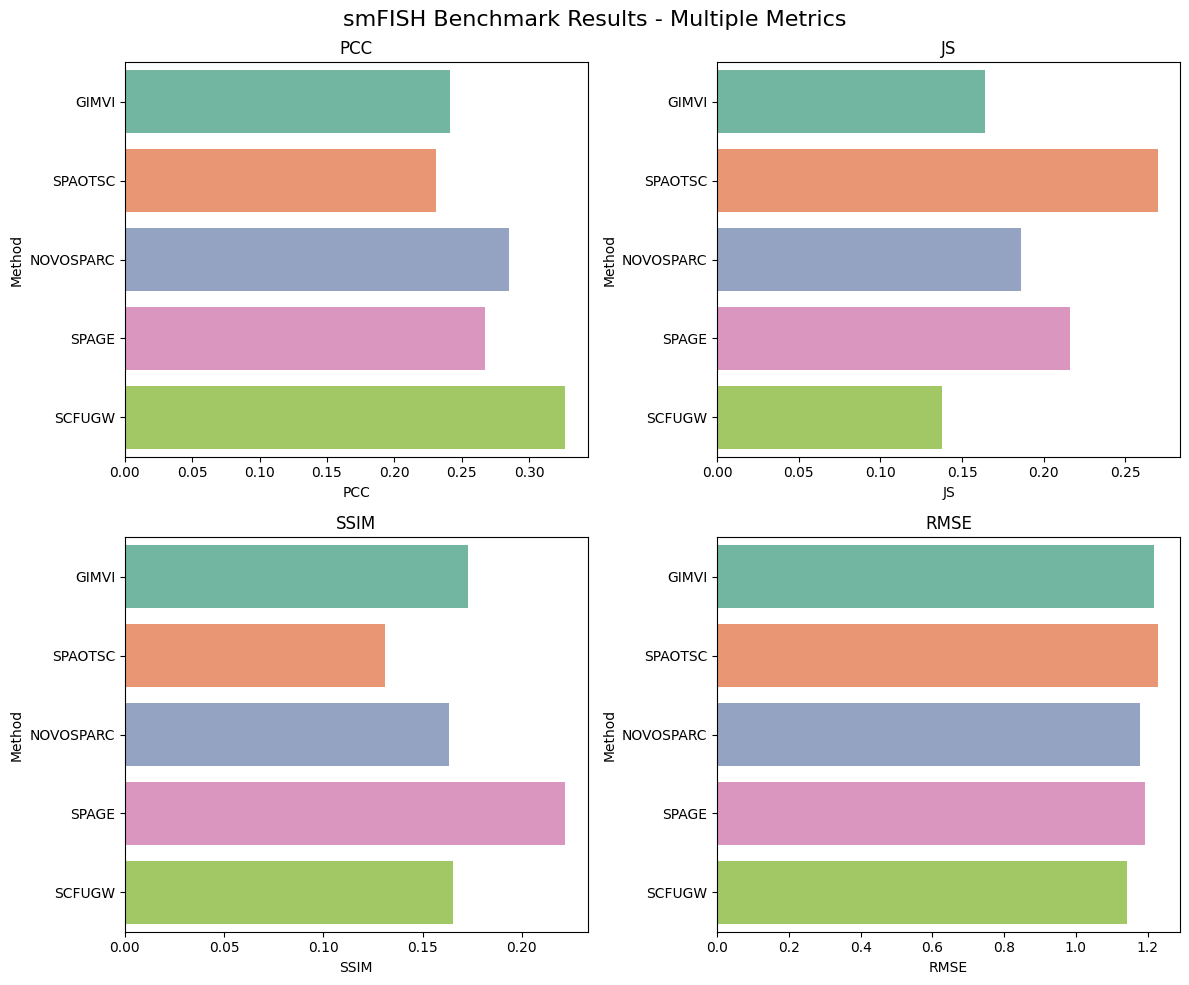

图表已保存为: smFISH_multi_metrics_benchmark.png


In [9]:
# 设置随机种子，保证结果可复现
np.random.seed(42)

# 指标名称
metrics = ['PCC', 'JS', 'SSIM', 'RMSE']

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 为每个指标绘制柱状图
for i, metric in enumerate(metrics):
    # 提取当前指标的数据，保持原始顺序
    tools_list = list(data.keys())
    values_list = [data[tool][i] for tool in tools_list]
    
    # 创建DataFrame，保持data字典的顺序
    df = pd.DataFrame({
        'tool': tools_list,
        metric: values_list
    })
    
    # 绘制横向柱状图（不进行排序，保持原始顺序）
    sns.barplot(
        data=df,
        x=metric,
        y="tool",
        palette="Set2",
        ax=axes[i],
        order=tools_list  # 明确指定顺序
    )
    
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Method")
    axes[i].set_title(f"{metric}")

plt.suptitle("smFISH Benchmark Results - Multiple Metrics", fontsize=16)
plt.tight_layout()
plt.savefig('smFISH_multi_metrics_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

print("图表已保存为: smFISH_multi_metrics_benchmark.png")


## 7. 绘制K-fold箱线图


In [5]:
def extract_fold_results(results_data: Dict[str, Dict]) -> pd.DataFrame:
    """
    从结果数据中提取每个fold的详细结果
    
    Args:
        results_data: 包含所有方法结果的字典
        
    Returns:
        pd.DataFrame: 包含所有fold结果的DataFrame
    """
    fold_data = []
    
    for method, data in results_data.items():
        if 'fold_results' in data:
            for fold_result in data['fold_results']:
                if fold_result['success']:  # 只包含成功的结果
                    fold_data.append({
                        'Method': method.upper(),
                        'Fold': fold_result['fold'],
                        'PCC': fold_result['PCC'],
                        'JS': fold_result['JS'],
                        'SSIM': fold_result['SSIM'],
                        'RMSE': fold_result['RMSE']
                    })
    
    return pd.DataFrame(fold_data)

# 提取fold结果数据
fold_df = extract_fold_results(results_data)
print(f"提取了 {len(fold_df)} 个fold结果")
print(f"包含 {fold_df['Method'].nunique()} 个方法")
print(f"每个方法的fold数量: {fold_df.groupby('Method')['Fold'].count().to_dict()}")

# 显示前几行数据
print("\n前5行数据:")
print(fold_df.head())


提取了 50 个fold结果
包含 5 个方法
每个方法的fold数量: {'GIMVI': 10, 'NOVOSPARC': 10, 'SCFUGW': 10, 'SPAGE': 10, 'SPAOTSC': 10}

前5行数据:
  Method  Fold       PCC        JS      SSIM      RMSE
0  GIMVI     1  0.284570  0.155064  0.230463  1.196157
1  GIMVI     2  0.351547  0.110812  0.273244  1.121224
2  GIMVI     3  0.353026  0.186076  0.258286  1.117666
3  GIMVI     4  0.274964  0.135374  0.215955  1.176902
4  GIMVI     5  0.031007  0.154840  0.036302  1.390589


/tmp/ipykernel_136618/1769390445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_136618/1769390445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_136618/1769390445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_136618/1769390445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


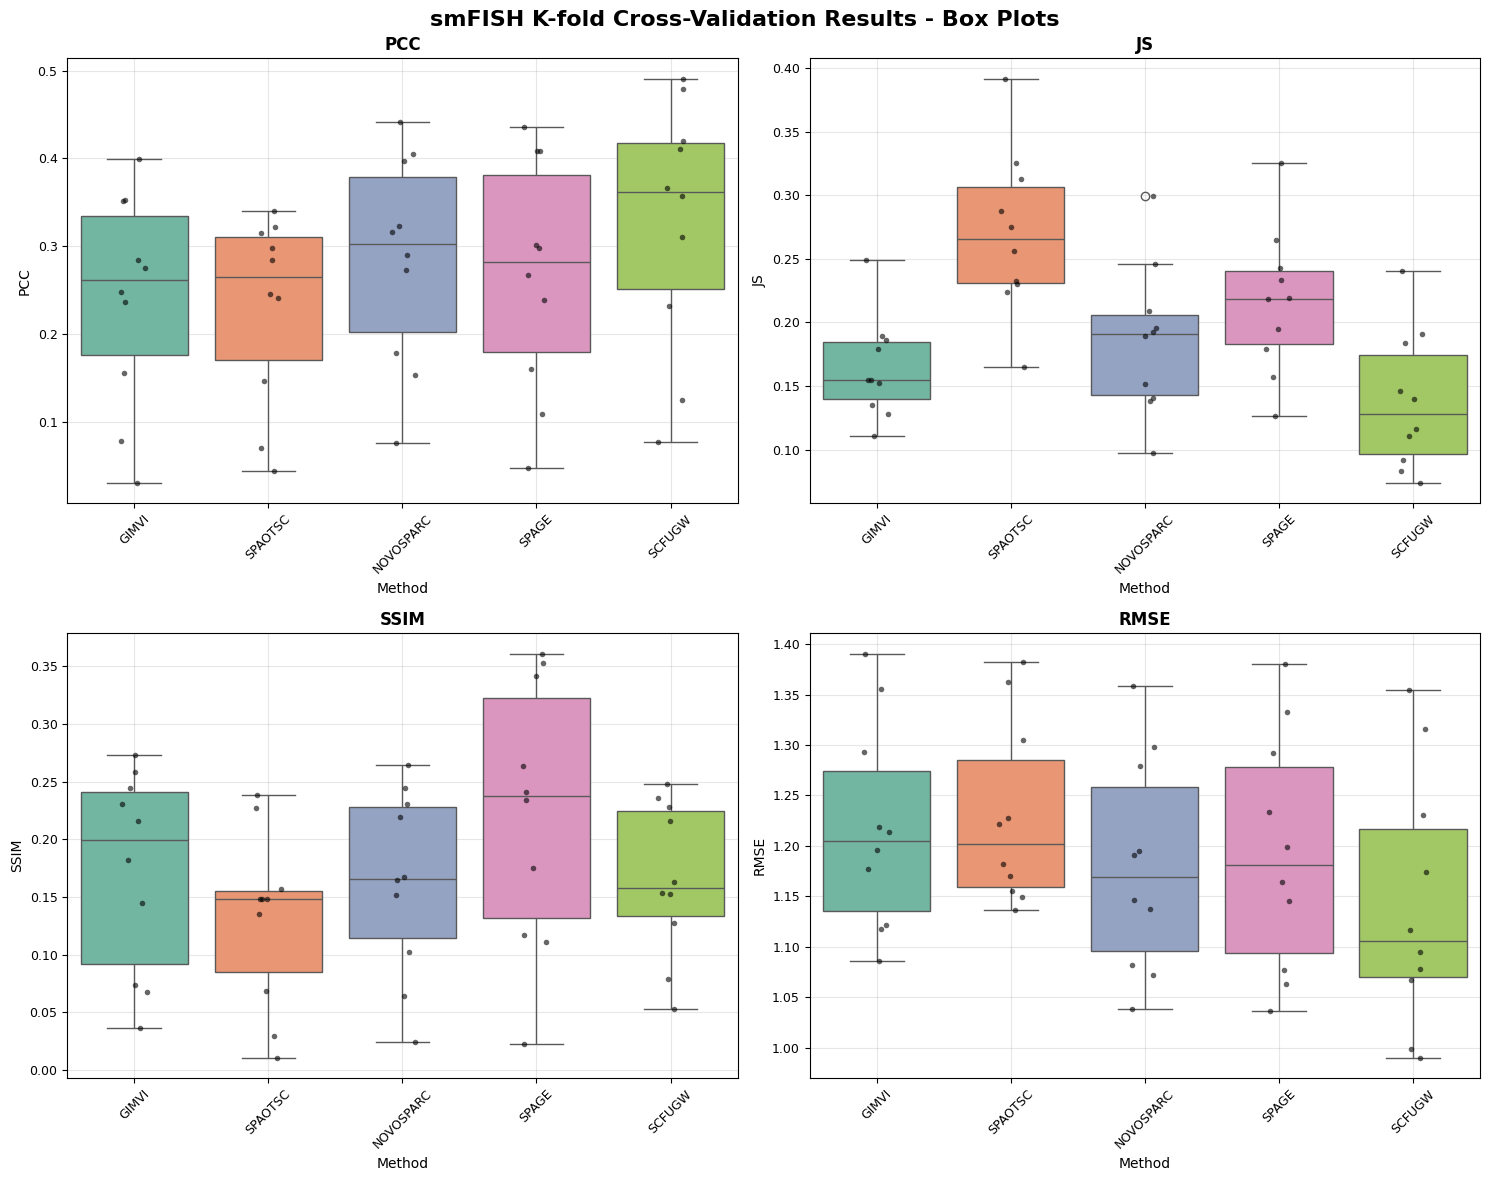

K-fold箱线图已保存为: smFISH_kfold_boxplots.png


In [8]:
# 绘制K-fold箱线图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

metrics = ['PCC', 'JS', 'SSIM', 'RMSE']
titles = ['PCC', 'JS', 'SSIM', 'RMSE']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    
    # 绘制箱线图
    sns.boxplot(
        data=fold_df,
        x='Method',
        y=metric,
        palette="Set2",
        ax=ax
    )
    
    # 添加散点图显示每个fold的点
    sns.stripplot(
        data=fold_df,
        x='Method',
        y=metric,
        color='black',
        alpha=0.6,
        size=4,
        ax=ax
    )
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    # 添加网格
    ax.grid(True, alpha=0.3)

plt.suptitle('smFISH K-fold Cross-Validation Results - Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('smFISH_kfold_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("K-fold箱线图已保存为: smFISH_kfold_boxplots.png")


/tmp/ipykernel_136618/39691106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_136618/39691106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_136618/39691106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_136618/39691106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_136618/39691106.py:37: UserWarnin

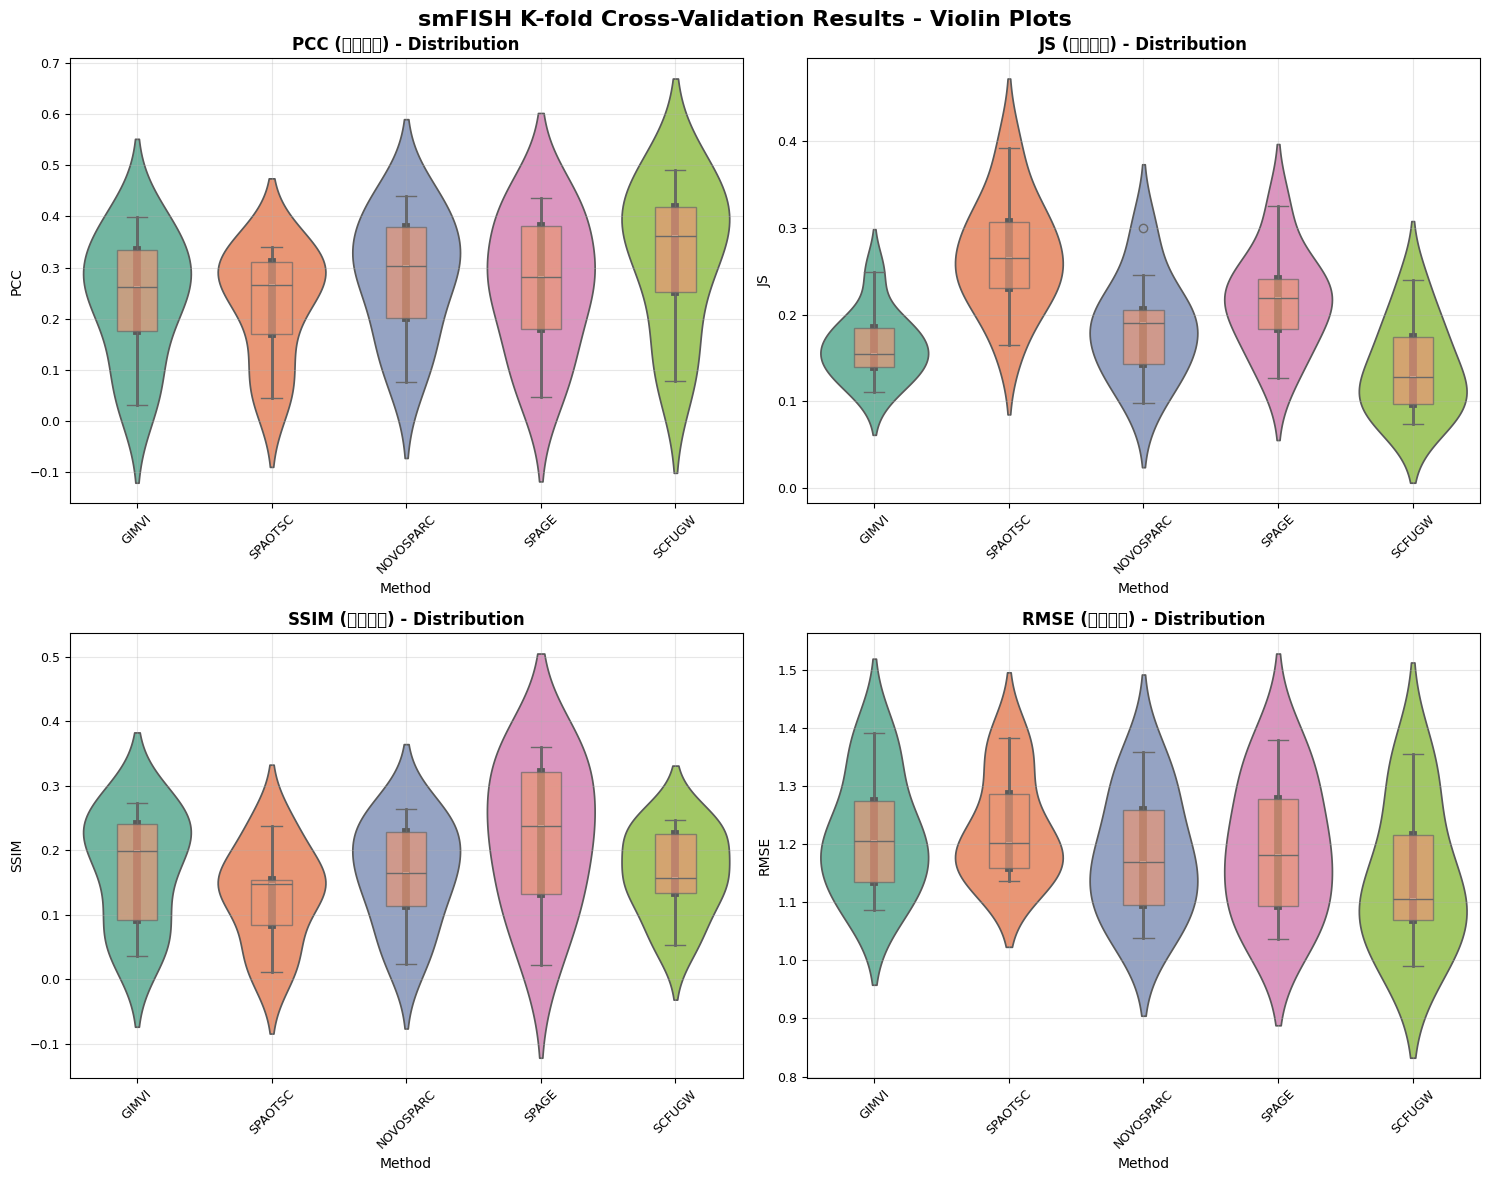

K-fold小提琴图已保存为: smFISH_kfold_violin_plots.png


In [7]:
# 绘制小提琴图（更详细的分布信息）
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    
    # 绘制小提琴图
    sns.violinplot(
        data=fold_df,
        x='Method',
        y=metric,
        palette="Set2",
        ax=ax
    )
    
    # 添加箱线图叠加
    sns.boxplot(
        data=fold_df,
        x='Method',
        y=metric,
        width=0.3,
        boxprops={'alpha': 0.7},
        ax=ax
    )
    
    ax.set_title(f'{title} - Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    
    # 添加网格
    ax.grid(True, alpha=0.3)

plt.suptitle('smFISH K-fold Cross-Validation Results - Violin Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('smFISH_kfold_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("K-fold小提琴图已保存为: smFISH_kfold_violin_plots.png")


In [ ]:
# 统计每个方法的fold结果
print("=== K-fold结果统计 ===")
for method in fold_df['Method'].unique():
    method_data = fold_df[fold_df['Method'] == method]
    print(f"\n{method}:")
    for metric in metrics:
        values = method_data[metric]
        print(f"  {metric}: 均值={values.mean():.4f}, 标准差={values.std():.4f}, 范围=[{values.min():.4f}, {values.max():.4f}]")

# 导出fold结果到CSV
fold_df.to_csv('smFISH_kfold_detailed_results.csv', index=False)
print(f"\n详细fold结果已导出到: smFISH_kfold_detailed_results.csv")
print(f"总共 {len(fold_df)} 个fold结果")
